In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('part1_pricing_gradient_descent_dirty.csv')

In [4]:
df.head()

,demand_index,time_slot,day_of_week,competition_pressure,operational_cost,seasonality_index,marketing_intensity,dynamic_price
0,89.0,27.0,3.0,0.09,99.70,0.88,NaN,363.653116
1,NaN,-4.0,7.0,0.98,184.11,0.55,0.88,440.052599
2,46.0,1.0,8.0,0.19,104.24,1.24,NaN,296.086005
3,78.0,15.0,2.0,0.91,102.99,1.10,0.75,325.169950
4,-3.0,NaN,8.0,1.01,174.56,0.59,0.38,164.465739


In [5]:
df.columns

Index(['demand_index', 'time_slot', 'day_of_week', 'competition_pressure',
       'operational_cost', 'seasonality_index', 'marketing_intensity',
       'dynamic_price'],
      dtype='object')

In [6]:
df.isna().sum()

demand_index            160
time_slot               160
day_of_week             160
competition_pressure    160
operational_cost        160
seasonality_index       160
marketing_intensity     160
dynamic_price           160
dtype: int64

In [7]:
df.shape

(2000, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   demand_index          1840 non-null   float64
 1   time_slot             1840 non-null   float64
 2   day_of_week           1840 non-null   float64
 3   competition_pressure  1840 non-null   float64
 4   operational_cost      1840 non-null   float64
 5   seasonality_index     1840 non-null   float64
 6   marketing_intensity   1840 non-null   float64
 7   dynamic_price         1840 non-null   float64
dtypes: float64(8)
memory usage: 125.1 KB


In [9]:
df.describe()

,demand_index,time_slot,day_of_week,competition_pressure,operational_cost,seasonality_index,marketing_intensity,dynamic_price
count,1840.000000,1840.000000,1840.000000,1840.000000,1840.000000,1840.000000,1840.000000,1840.000000
mean,54.485326,12.019022,4.000000,0.701870,119.602886,0.995027,0.551799,290.162921
std,43.697447,9.265298,2.591449,0.518466,39.803170,0.287712,0.426033,140.761588
min,-20.000000,-4.000000,0.000000,-0.200000,-18.450000,0.500000,-0.200000,6.081920
25%,16.000000,4.000000,2.000000,0.250000,92.477500,0.750000,0.187500,200.575546
50%,55.000000,12.000000,4.000000,0.710000,119.885000,1.000000,0.555000,281.926581
75%,92.000000,20.000000,6.000000,1.140000,146.232500,1.240000,0.910000,359.650735
max,129.000000,27.000000,8.000000,1.600000,254.950000,1.500000,1.300000,1455.215971


In [10]:
# Supprimer lignes sans target
df = df.dropna(subset=['dynamic_price'])


In [11]:
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')


for col in ['demand_index', 'time_slot', 'day_of_week', 
            'competition_pressure', 'operational_cost', 
            'seasonality_index', 'marketing_intensity']:
    df[col].fillna(df[col].median(), inplace=True)


In [12]:
df.isna().sum()

demand_index            0
time_slot               0
day_of_week             0
competition_pressure    0
operational_cost        0
seasonality_index       0
marketing_intensity     0
dynamic_price           0
dtype: int64

In [13]:
features = ['demand_index', 'time_slot', 'day_of_week', 
            'competition_pressure', 'operational_cost', 
            'seasonality_index', 'marketing_intensity']

In [14]:
X = df[features].values
y = df['dynamic_price'].values.reshape(-1,1)

In [15]:
# Feature scaling (important for gradient descent)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

In [16]:
X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [18]:
def batch_gradient_descent(X, y, alpha=0.001, iterations=1000):
    m = len(y)
    theta = np.zeros((X.shape[1], 1))
    cost_history = []

    for _ in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradient = (1/m) * X.T.dot(errors)
        theta -= alpha * gradient
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)

    return theta, cost_history

In [38]:
def stochastic_gradient_descent(X, y, alpha=0.001, epochs=100):
    """Stochastic Gradient Descent - one sample per update"""
    m = len(y)
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        total_cost = 0
        
        for idx in indices:
            x_i = X[idx:idx+1, :]
            y_i = y[idx:idx+1, :]
            prediction = x_i.dot(theta)
            error = prediction - y_i
            gradient = x_i.T.dot(error)
            theta -= alpha * gradient
            total_cost += (error ** 2)[0, 0]
        
        avg_cost = total_cost / (2 * m)
        cost_history.append(avg_cost)
    
    return theta, cost_history



In [33]:
def mini_batch_gradient_descent(X, y, alpha=0.001, epochs=100, batch_size=32):
    """Mini-Batch Gradient Descent - small batches per update"""
    m = len(y)
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        total_cost = 0
        num_batches = 0
        
        for start in range(0, m, batch_size):
            end = min(start + batch_size, m)
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            batch_m = len(y_batch)
            
            predictions = X_batch.dot(theta)
            errors = predictions - y_batch
            gradient = (1/batch_m) * X_batch.T.dot(errors)
            theta -= alpha * gradient
            
            batch_cost = (1/(2*batch_m)) * np.sum(errors ** 2)
            total_cost += batch_cost
            num_batches += 1
        
        avg_cost = total_cost / num_batches
        cost_history.append(avg_cost)
    
    return theta, cost_history

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(theta, X_test, y_test):
    """Evaluate model performance"""
    y_pred = X_test.dot(theta)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return y_pred, mse, rmse, r2

In [35]:
import matplotlib.pyplot as plt
def plot_results(y_test, y_pred, cost_history, method_name):
    """Plot actual vs predicted and cost history"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Actual vs Predicted
    axes[0].scatter(y_test, y_pred, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', lw=2)
    axes[0].set_xlabel('Actual Prices')
    axes[0].set_ylabel('Predicted Prices')
    axes[0].set_title(f'Actual vs Predicted - {method_name}')
    axes[0].grid(True, alpha=0.3)
    
    # Cost history
    axes[1].plot(cost_history)
    axes[1].set_xlabel('Iterations/Epochs')
    axes[1].set_ylabel('Cost')
    axes[1].set_title(f'Cost History - {method_name}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [36]:
def compare_gradient_descent_methods(X_train, y_train, X_test, y_test, features):
    results = {}

    print("=" * 60)
    print("BATCH GRADIENT DESCENT")
    print("=" * 60)
    theta_batch, cost_batch = batch_gradient_descent(
        X_train, y_train, alpha=0.01, iterations=1000)

    y_pred_batch, mse_batch, rmse_batch, r2_batch = evaluate_model(
        theta_batch, X_test, y_test
    )

    results['batch'] = {
        'theta': theta_batch,
        'cost_history': cost_batch,
        'mse': mse_batch,
        'rmse': rmse_batch,
        'r2': r2_batch
    }

    plot_results(y_test, y_pred_batch, cost_batch, "Batch GD")

    print("\n" + "=" * 60)
    print("STOCHASTIC GRADIENT DESCENT")
    print("=" * 60)
    theta_stochastic, cost_stochastic = stochastic_gradient_descent(
        X_train, y_train, alpha=0.001, epochs=50)

    y_pred_stochastic, mse_stochastic, rmse_stochastic, r2_stochastic = evaluate_model(
        theta_stochastic, X_test, y_test
    )

    results['stochastic'] = {
        'theta': theta_stochastic,
        'cost_history': cost_stochastic,
        'mse': mse_stochastic,
        'rmse': rmse_stochastic,
        'r2': r2_stochastic
    }

    plot_results(y_test, y_pred_stochastic, cost_stochastic, "Stochastic GD")

    print("\n" + "=" * 60)
    print("MINI-BATCH GRADIENT DESCENT")
    print("=" * 60)
    theta_minibatch, cost_minibatch = mini_batch_gradient_descent(
        X_train, y_train, alpha=0.01, epochs=100, batch_size=32)

    y_pred_minibatch, mse_minibatch, rmse_minibatch, r2_minibatch = evaluate_model(
        theta_minibatch, X_test, y_test
    )

    results['minibatch'] = {
        'theta': theta_minibatch,
        'cost_history': cost_minibatch,
        'mse': mse_minibatch,
        'rmse': rmse_minibatch,
        'r2': r2_minibatch
    }

    plot_results(y_test, y_pred_minibatch, cost_minibatch, "Mini-Batch GD")

    print("\n" + "=" * 60)
    print("COMPARISON SUMMARY")
    print("=" * 60)
    print(f"{'Method':<20} {'MSE':<12} {'RMSE':<12} {'R²':<12}")
    print("-" * 60)
    print(f"{'Batch GD':<20} {mse_batch:<12.4f} {rmse_batch:<12.4f} {r2_batch:<12.4f}")
    print(f"{'Stochastic GD':<20} {mse_stochastic:<12.4f} {rmse_stochastic:<12.4f} {r2_stochastic:<12.4f}")
    print(f"{'Mini-Batch GD':<20} {mse_minibatch:<12.4f} {rmse_minibatch:<12.4f} {r2_minibatch:<12.4f}")

    return results


Starting gradient descent comparison...
BATCH GRADIENT DESCENT


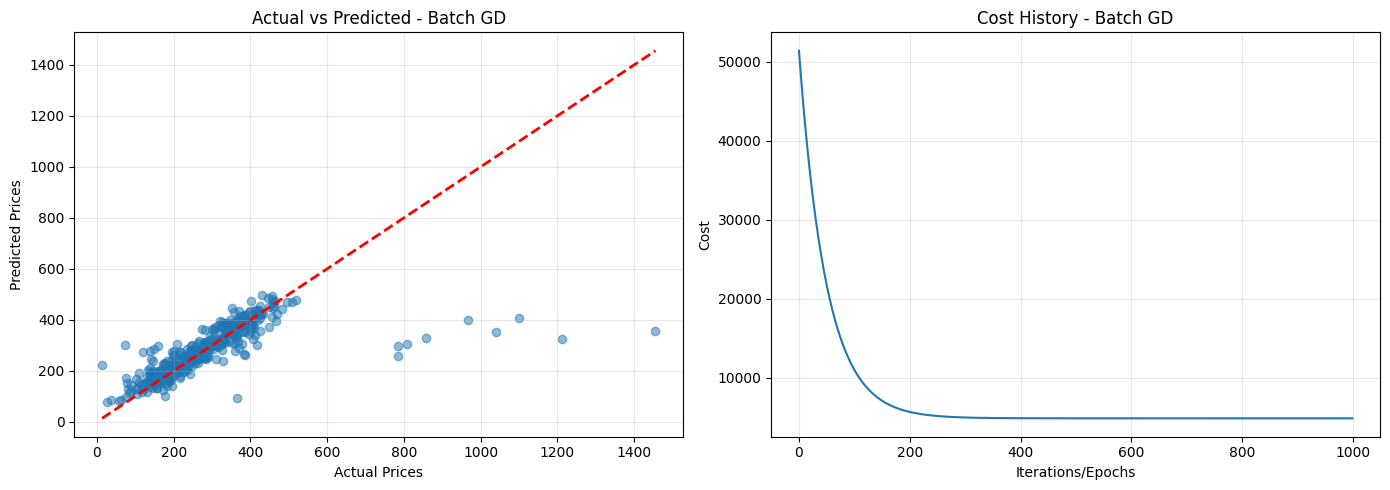


STOCHASTIC GRADIENT DESCENT


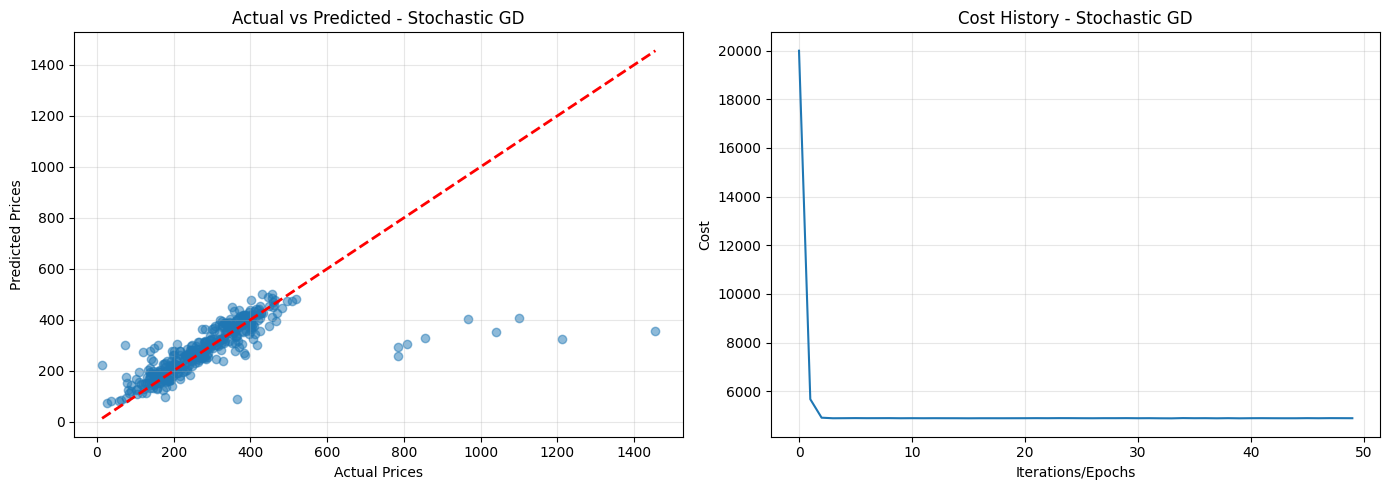


MINI-BATCH GRADIENT DESCENT


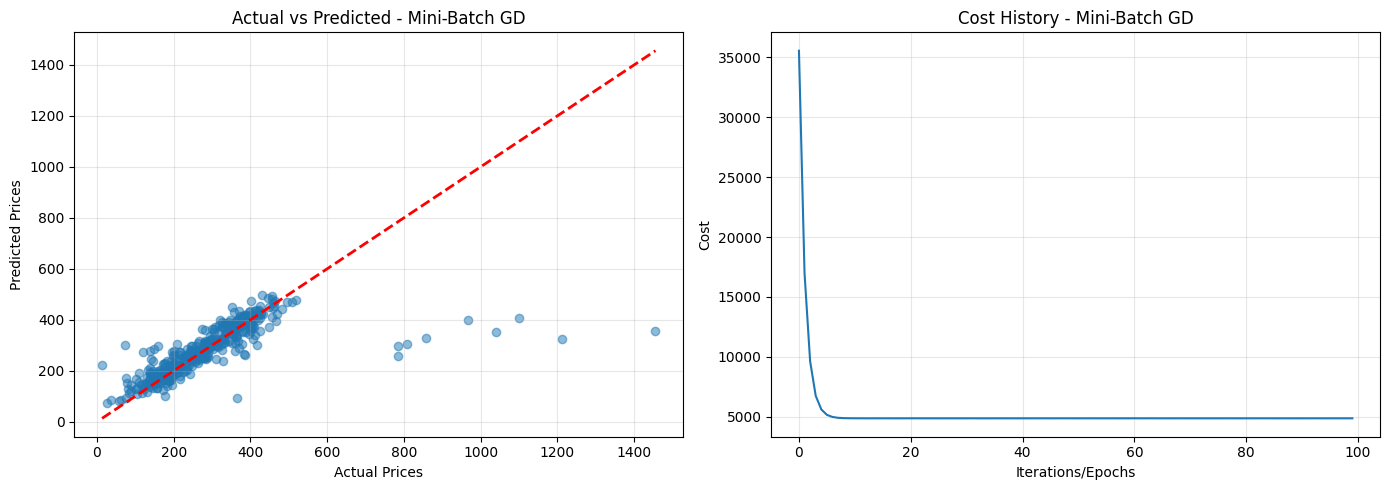


COMPARISON SUMMARY
Method               MSE          RMSE         R²          
------------------------------------------------------------
Batch GD             13774.6402   117.3654     0.4359      
Stochastic GD        13770.3758   117.3472     0.4360      
Mini-Batch GD        13766.8392   117.3322     0.4362      


In [37]:
print("Starting gradient descent comparison...")
results = compare_gradient_descent_methods(
    X_train, y_train, X_test, y_test, features
)

In [ ]:
import numpy as np

def save_model(filepath, theta, X_mean, X_std, features):
    np.savez(
        filepath,
        theta=theta,
        X_mean=X_mean,
        X_std=X_std,
        features=np.array(features)
    )
    print(f"Model saved to {filepath}")

In [ ]:
save_model(
    "pricing_model_sgd.npz",
    theta=results['stochastic']['theta'],
    X_mean=X_mean,
    X_std=X_std,
    features=features
)

Model saved to pricing_model_sgd.npz
